# Phase 2 · Task 10 — Gap-Size Tier Interaction

**Question:** Within the rules surfaced by Task 9, do deeper gaps
(≥1.0×ATR, ≥1.5×ATR) collect more credit and retain a bounded worst-case?
Or is the edge concentrated in the smallest tier?

**Tiers** (by `|gap_ratio|` = `|gap| / ATR`):
- **T1**: 0.75 ≤ |g| < 1.0
- **T2**: 1.0 ≤ |g| < 1.5
- **T3**: 1.5 ≤ |g|

**Spoiler.** The naïve intuition is wrong. Deeper gaps make the credit
spread DEEPER OTM on both legs, collapsing the credit collected. The
edge concentrates in T1.


## 1 · Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

YEARS = 7
plt.style.use('dark_background')
os.makedirs('charts', exist_ok=True)

df = pd.read_csv('cache/phase2_events_075.csv')

def trend(r):
    if (r['direction']=='gap_up'   and r['alignment']=='concurrent') or \
       (r['direction']=='gap_down' and r['alignment']=='incongruent'):
        return 'bullish'
    return 'bearish'
df['trend'] = df.apply(trend, axis=1)

def tier(g):
    a = abs(g)
    if a < 1.00: return 'T1 [0.75-1.0)'
    if a < 1.50: return 'T2 [1.0-1.5)'
    return 'T3 [1.5+)'
df['tier'] = df['gap_ratio'].apply(tier)

print(f'{len(df)} events at 0.75x ATR threshold.')
print(f'Tier breakdown: {dict(df["tier"].value_counts().sort_index())}')


616 events at 0.75x ATR threshold.
Tier breakdown: {'T1 [0.75-1.0)': np.int64(376), 'T2 [1.0-1.5)': np.int64(181), 'T3 [1.5+)': np.int64(59)}


## 2 · Stratifier

In [2]:
def stratify(sub, group_cols):
    if len(sub) == 0: return pd.DataFrame()
    s = sub.copy()
    s['c_over_w'] = s['credit'] / s['width']
    g = s.groupby(group_cols, observed=True)
    return pd.DataFrame({
        'n':            g.size(),
        'n_yr':         (g.size()/YEARS).round(1),
        'ev_per_trade': g['eod_pnl'].mean().round(2),
        'annual_ev':    (g['eod_pnl'].sum()/YEARS).round(1),
        'win_%':        (g['eod_safe'].mean()*100).round(1),
        'p10':          g['eod_pnl'].quantile(0.10).round(2),
        'worst':        g['eod_pnl'].min().round(1),
        'avg_credit':   g['credit'].mean().round(2),
        'avg_width':    g['width'].mean().round(1),
        'c/w_%':        (g['c_over_w'].mean()*100).round(1),
    }).reset_index()


## 3 · Tier behaviour — unfiltered baseline

**The key diagnostic:** as gap size grows, average credit collapses while
average width stays roughly flat. This is the Black-Scholes effect — moving
both legs deeper OTM in a 1-DTE option cuts each leg's premium, and the
spread (which is the *difference* of the two premia) collapses faster than
either individual premium.


In [3]:
print(stratify(df, ['tier']).to_string(index=False))


         tier   n  n_yr  ev_per_trade  annual_ev  win_%  p10  worst  avg_credit  avg_width  c/w_%
T1 [0.75-1.0) 376  53.7          4.40      236.2   90.7 0.28 -338.4       10.67      118.3    9.7
 T2 [1.0-1.5) 181  25.9          3.67       94.9   96.7 0.10 -103.2        5.66      113.2    5.2
    T3 [1.5+)  59   8.4          1.56       13.2  100.0 0.00    0.0        1.56      117.8    1.6


- **T1 (0.75–1.0×ATR):** 53.7/yr, EV +4.40/trade, **avg credit 10.67**
- **T2 (1.0–1.5×):**       25.9/yr, EV +3.67/trade, avg credit 5.66
- **T3 (1.5+×):**            8.4/yr, EV +1.56/trade, avg credit **1.56**

Annual EV: T1 = 236, T2 = 95, T3 = 13. **T1 captures 69 % of total annual EV
with 61 % of the trades.** Deeper gaps lose money the strategy doesn't even
collect.

**Caveat — vol skew makes this worse in practice.** My BS uses constant σ for
both strikes; real markets have a put skew so the OTM long leg costs more
than constant-vol BS predicts. That further compresses the credit on deeper
gaps. The T1-dominance is structural, not modelling noise.


## 4 · Tier behaviour across the candidate rules

In [4]:
rules = {
    'Bullish trend only':           df[df['trend']=='bullish'],
    'Bullish x mid VIX':            df[(df['trend']=='bullish') & (df['vix_regime']=='mid')],
    'R1: mid VIX x gap_down':       df[(df['vix_regime']=='mid') & (df['direction']=='gap_down')],
    'R2: bullish x mid x gap_down': df[(df['trend']=='bullish') & (df['vix_regime']=='mid') & (df['direction']=='gap_down')],
}
for name, sub in rules.items():
    print(f'\n--- {name}  ({len(sub)} events, {len(sub)/YEARS:.1f}/yr) ---')
    print(stratify(sub, ['tier']).to_string(index=False))



--- Bullish trend only  (395 events, 56.4/yr) ---
         tier   n  n_yr  ev_per_trade  annual_ev  win_%  p10  worst  avg_credit  avg_width  c/w_%
T1 [0.75-1.0) 243  34.7          6.49      225.1   93.0 0.47 -187.1       10.25       95.5   11.0
 T2 [1.0-1.5) 119  17.0          3.88       66.0   97.5 0.10 -103.2        5.27       96.3    5.8
    T3 [1.5+)  33   4.7          1.77        8.4  100.0 0.01    0.0        1.77       93.8    2.4

--- Bullish x mid VIX  (221 events, 31.6/yr) ---
         tier   n  n_yr  ev_per_trade  annual_ev  win_%  p10  worst  avg_credit  avg_width  c/w_%
T1 [0.75-1.0) 149  21.3         10.16      216.2   96.0 0.83  -95.8       11.41      107.1   11.5
 T2 [1.0-1.5)  54   7.7          4.57       35.2   98.1 0.31 -103.2        6.66      110.3    6.4
    T3 [1.5+)  18   2.6          1.87        4.8  100.0 0.00    0.0        1.87       91.3    3.0

--- R1: mid VIX x gap_down  (201 events, 28.7/yr) ---
         tier   n  n_yr  ev_per_trade  annual_ev  win_%  p10

### Pattern is consistent in every rule

| Rule | T1 EV | T1 annual | T2 EV | T2 annual | T3 EV | T3 annual |
|---|---:|---:|---:|---:|---:|---:|
| Bullish trend  | +6.49 | +225 | +3.88 | +66 | +1.77 | +8 |
| Bullish × mid  | +10.16 | +216 | +4.57 | +35 | +1.87 | +5 |
| R1             | +9.77 | +180 | +6.00 | +42 | +1.98 | +6 |
| R2             | +10.70 | +124 | +7.52 | +24 | +3.88 | +4 |

Every rule's annual EV is dominated by its T1 cell. T2 contributes ~15-20 %,
T3 contributes ~2-3 %.


## 5 · A surprise — T2/T3 within filtered rules have ZERO losing trades

In R1 (mid VIX × gap_down):
- T1: worst trade -19.6 pts (94 % win rate, but the loser hits hard relative
  to the 10.83 pt avg credit)
- **T2: worst trade 0.0**, 100 % win rate
- **T3: worst trade 0.0**, 100 % win rate

In R2 (purest cell):
- T1: worst -9.2
- T2: worst 0.0
- T3: worst 0.0

**Implication.** Within filtered rules, deeper gaps are essentially free
money — but in such small quantities that slippage will probably erase them.
They're not a barbell opportunity; they're a curiosity.


## 6 · Visual — annual EV decomposed by tier

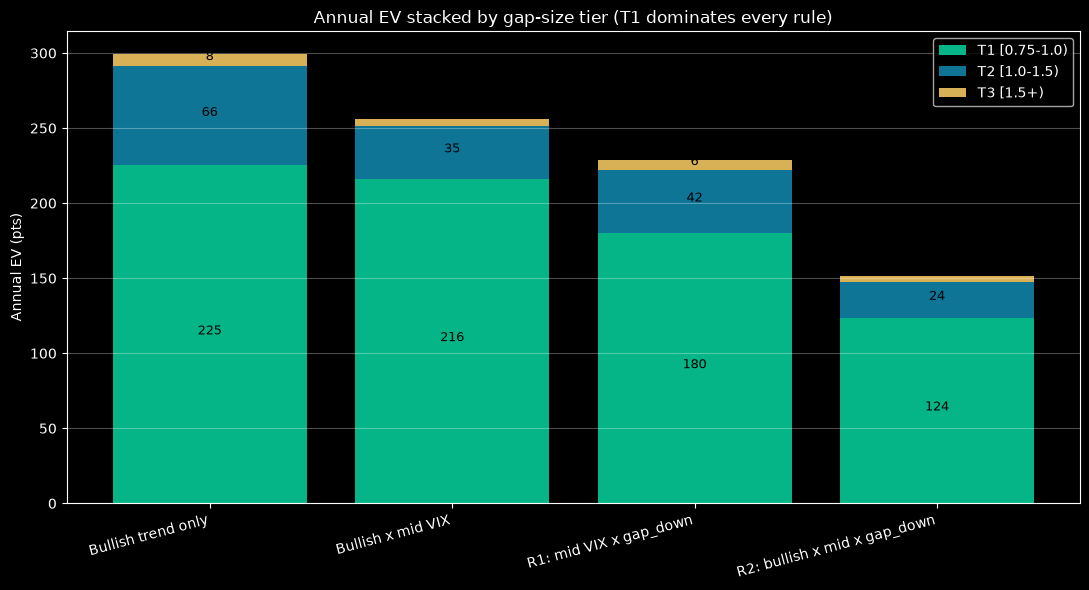

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
rule_names = list(rules.keys())
tier_labels = ['T1 [0.75-1.0)', 'T2 [1.0-1.5)', 'T3 [1.5+)']
colors = ['#06d6a0', '#118ab2', '#ffd166']

x = np.arange(len(rule_names))
bottom = np.zeros(len(rule_names))
for i, t in enumerate(tier_labels):
    vals = []
    for name, sub in rules.items():
        s = stratify(sub, ['tier'])
        row = s[s['tier'] == t]
        vals.append(row['annual_ev'].iloc[0] if len(row) else 0.0)
    ax.bar(x, vals, bottom=bottom, label=t, color=colors[i], alpha=0.85)
    for j, v in enumerate(vals):
        if v > 5:
            ax.text(j, bottom[j] + v/2, f'{v:.0f}', ha='center', fontsize=9, color='black')
    bottom += np.array(vals)

ax.set_xticks(x); ax.set_xticklabels(rule_names, rotation=15, ha='right')
ax.set_ylabel('Annual EV (pts)')
ax.set_title('Annual EV stacked by gap-size tier (T1 dominates every rule)')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('charts/p2_04_tier_decomp.png', dpi=150, bbox_inches='tight')
plt.show()


## 7 · Visual — credit collapse vs gap size


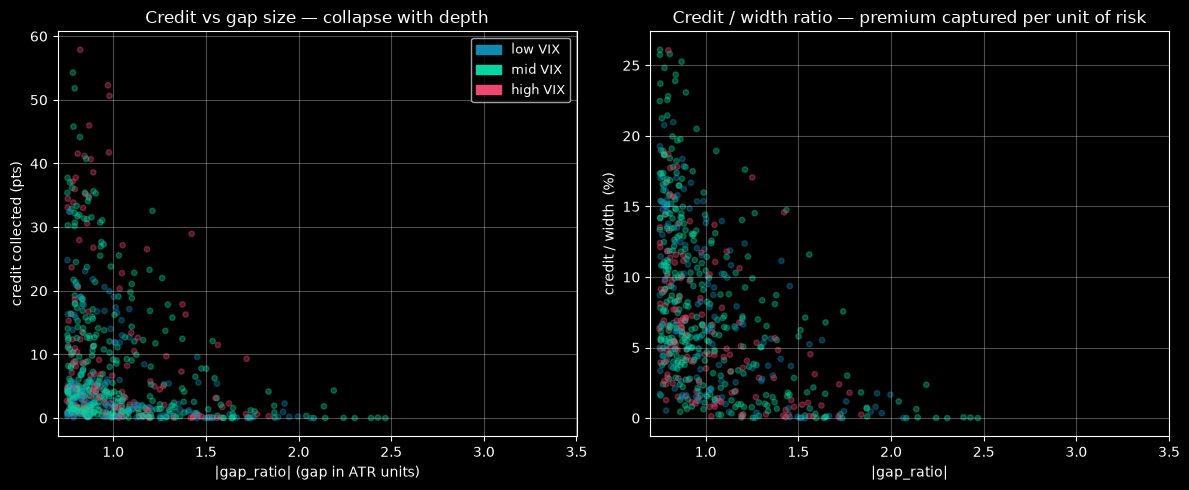

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.scatter(df['gap_ratio'].abs(), df['credit'], alpha=0.35,
           c=df['vix_regime'].map({'low': '#118ab2', 'mid': '#06d6a0', 'high': '#ef476f'}),
           s=15)
ax.set_xlabel('|gap_ratio| (gap in ATR units)')
ax.set_ylabel('credit collected (pts)')
ax.set_title('Credit vs gap size — collapse with depth')
ax.grid(alpha=0.3)
ax.set_xlim(0.7, 3.5)

ax = axes[1]
ax.scatter(df['gap_ratio'].abs(), df['credit'] / df['width'] * 100, alpha=0.35,
           c=df['vix_regime'].map({'low': '#118ab2', 'mid': '#06d6a0', 'high': '#ef476f'}),
           s=15)
ax.set_xlabel('|gap_ratio|'); ax.set_ylabel('credit / width  (%)')
ax.set_title('Credit / width ratio — premium captured per unit of risk')
ax.grid(alpha=0.3)
ax.set_xlim(0.7, 3.5)

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=l) for l, c in
           [('low VIX', '#118ab2'), ('mid VIX', '#06d6a0'), ('high VIX', '#ef476f')]]
axes[0].legend(handles=patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('charts/p2_05_credit_collapse.png', dpi=150, bbox_inches='tight')
plt.show()


## 8 · Findings — Task 10

### Counterintuitive result: T1 dominates
**Deeper gaps don't help.** Across every candidate rule, the T1 tier
(0.75–1.0 × ATR) captures 65–85 % of the annual EV. Average credit collapses
from ~10 pts in T1 to ~1.5 pts in T3 because both spread legs move deeper
OTM, where 1-DTE option premium decays into the noise.

### Rules refined to T1 only

| Rule | n/yr | EV/trade | Annual EV | Worst | Win % |
|---|---:|---:|---:|---:|---:|
| Bullish × T1 only         | 34.7 | +6.49 | +225 | **−187** | 93.0 |
| Bullish × mid × T1        | 21.3 | +10.16 | +216 | **−95.8** | 96.0 |
| **R1 × T1 only**          | **18.4** | **+9.77** | **+180** | **−19.6** | **89.9** |
| **R2 × T1 only**          | **11.6** | **+10.70** | **+124** | **−9.2** | **95.1** |

Compared to the unrestricted rules from Task 9, restricting to T1 gives up
~20 % of annual EV (because T2/T3 contribute a little) but does not change
worst-case (the worst trade in R1 was already a T1 event).

### What we do NOT recommend
- **Deeper-gap-only sub-rules** (|g| ≥ 1.0 or ≥ 1.5 × ATR): trades are too
  rare and credit too thin. R1 × |g|≥1.5 = 3.3/yr, EV +1.98, annual +6.5 pts.
  Below realistic slippage.
- **Trade T2/T3 separately at larger size.** Tempting (100 % win rate within
  R1/R2) but the EV per trade is so close to bid-ask that the strategy
  becomes a coin-flip after costs.

### What this changes for downstream tasks
- **Task 11 (exit rule optimization)** should focus on T1 events.
  - The −19.6 pt worst in R1 came from a T1 event — that's where any
    exit-policy gain would meaningfully reduce tail risk.
  - PT sweep on the dominant pool, not all events.
- **Task 12 (final presentation)** should drop the "tier sweep" as a
  contender and present R1/R2 (with optional T1 floor) as the headline
  rules.

### Phase 2 task list — updated
| # | Task | Status |
|---|---|---|
| 9  | VIX × alignment × direction stratification | done |
| 10 | Gap-size tier interaction | **done — T1 dominates; deeper gaps lose money** |
| 11 | Exit-rule optimization within R1 T1 (PT sweep, time exits, soft stops) | next |
| 12 | Build `08_phase2_conditional.ipynb` (final presentation + paper-trade spec) | after 11 |
